![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [3]:
x = df["math score"].to_numpy()

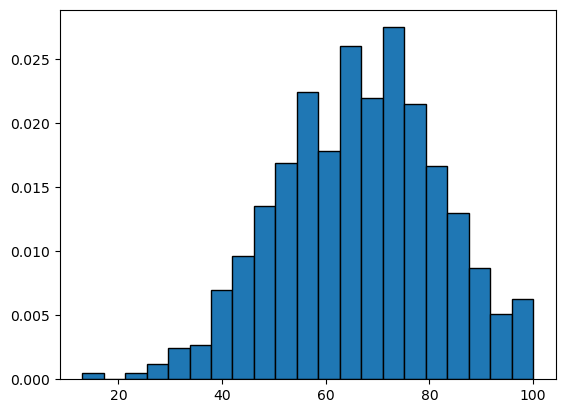

In [4]:
plt.hist(x,bins="auto",edgecolor="black",density=True)
pass

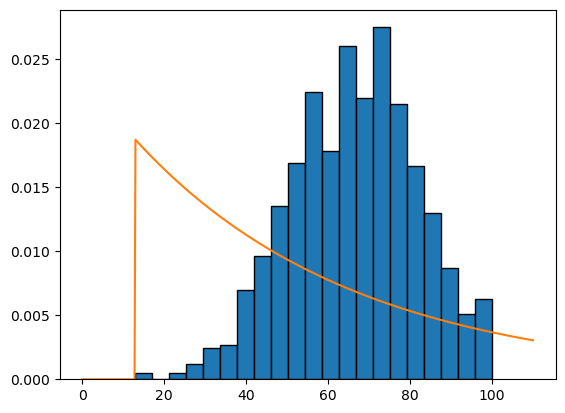

In [12]:
#rozklad nie pasuje, zły dobór rozkładu
R = st.expon
parametry = R.fit(x)
RE = R(parametry[0], parametry[1])

plt.hist(x,bins="auto",edgecolor="black",density=True)
t = np.linspace(0,110,500)
plt.plot(t,RE.pdf(t))
pass

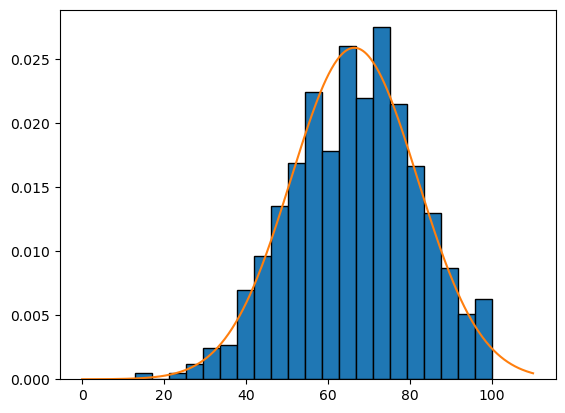

In [13]:
R = st.norm #wybór klasy rozkładu
parametry = R.fit(x) #estymacja parametrów
RE = R(*parametry) #utworzenie instancji rozkładu, operator rozpakowania

plt.hist(x,bins="auto",edgecolor="black",density=True)
t = np.linspace(0,110,500)
plt.plot(t,RE.pdf(t))
pass

In [14]:
RE.mean()

66.396

In [16]:
1-RE.cdf(100)

0.01452663893599715

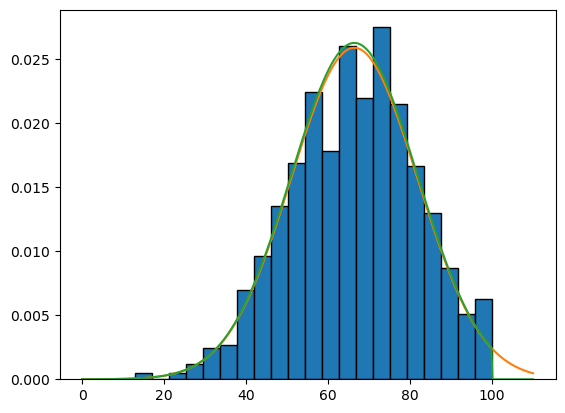

In [24]:
m = RE.mean()
s = RE.std()

at = 0
bt = 100

a, b = (at - m) / s, (bt - m) / s

REP = st.truncnorm(a,b, m, s)

plt.hist(x,density=True,bins="auto",edgecolor="black")
t = np.linspace(0,110,500)
plt.plot(t,RE.pdf(t))
plt.plot(t,REP.pdf(t))
pass

#### Estymacja parametrów rozkładu normalnego
Poniżej wykorzystano metodę `fit` do określenia parametrów ($\mu$ - wartość oczekiwana, $s$ - odchylenie standardowe) rozkładu normalnego.

In [5]:
parametry_est = st.norm.fit(x)
parametry_est

(66.396, 15.395167553488985)

Następnie utworzony został obiekt rozkładu na podstawie estymoanych parametrów.

In [6]:
rozklad_normalny_estymowany = st.norm(*parametry_est)
rozklad_normalny_estymowany

W celu porównania histogramu oraz gęstości estymowanego rozkładu należy wykonać wykres.

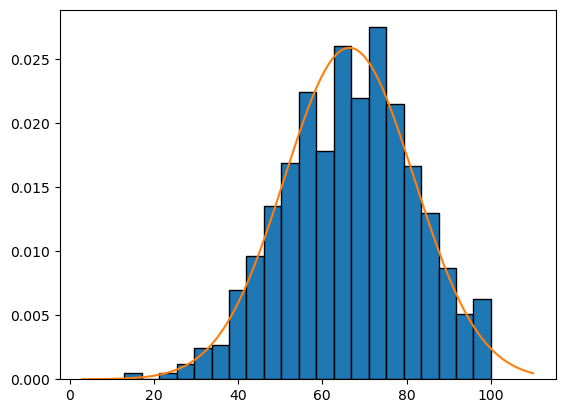

In [7]:
plt.hist(x,bins="auto",edgecolor="black",density=True)
t = np.linspace(min(x)-10,max(x)+10,1000)
plt.plot(t,rozklad_normalny_estymowany.pdf(t))
pass

#### Estymacja rozkładu normalnego ucinanego

Punkty z egzaminu mieszczą się w zakresie od 0 do 100, natomiast dziedziną rozkładu normalnego jest zakres $[-\infty,+\infty]$. Oznacza to, że pole pod gęstością rozkładu w zakresie $[0,100]$ nie będzie równe $1$: 

In [27]:
rozklad_normalny_estymowany.cdf(100) - rozklad_normalny_estymowany.cdf(0)

NameError: name 'rozklad_normalny_estymowany' is not defined

W praktyce wynikający z tego błąd może zostać zaniedbany. Jeśli jednak zależy nam na dokładności można użyć rozkładu ucinanego. Oznacza to, że pole znajdujące się poza zadanym zakresem $[a,b]$ zostanie równo rozłożone pod gęstością rozkładu. W bibliotece `scipy.stats` występuje obiekt [rozkładu normalnego ucinanego](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.truncnorm.html). W celu utworzenia jego instancji należy przekazać wartości ograniczające przedziału $[a,b]$ oraz estymowane wcześniej parametry rozkładu normalnego.

In [26]:
m = rozklad_normalny_estymowany.mean()
s = rozklad_normalny_estymowany.std()
a = 0
b = 100

# przeliczenie granic przedziału ograniczającego do wartości standardyzowanych
scaled_a = (a - m) / s
scaled_b = (b - m) / s
# utworzenie obiektu rozkładu
rozklad_normalny_ucinany = st.truncnorm(scaled_a,scaled_b,m,s)

NameError: name 'rozklad_normalny_estymowany' is not defined

Na poniższym wykresie można zauważyć, że poza zakresem $[a,b]$ gęstość rozkładu jest równa zeru.

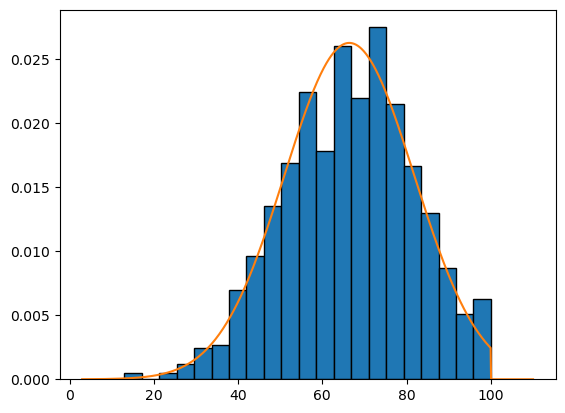

In [10]:
plt.hist(x,bins="auto",edgecolor="black",density=True)
t = np.linspace(min(x)-10,max(x)+10,1000)
plt.plot(t,rozklad_normalny_ucinany.pdf(t))
pass

Natomiast pole pod gęstością rozkładu w zakresie $[a,b]$ jest równe $1$.

In [25]:
rozklad_normalny_ucinany.cdf(b) - rozklad_normalny_ucinany.cdf(a)

NameError: name 'rozklad_normalny_ucinany' is not defined